# Clinical GraphRAG Quick Start

This notebook runs through the Quick Start pipeline (Steps 0–5) from the README.

**Prerequisites:**
- [uv](https://docs.astral.sh/uv/getting-started/installation/) installed
- **API key:** Create `api_keys.json` with your OpenRouter key (see Step 1 below)

**Excluded:** Step 7 (LLM Judge) — optional and costly.

## Setup: Ensure we're in the project root

In [ ]:
import os
from pathlib import Path

# Ensure we're in project root (parent of notebooks/)
cwd = Path.cwd()
if (cwd / "pyproject.toml").exists():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent
    os.chdir(PROJECT_ROOT)

print(f"Project root: {Path.cwd()}")

## Step 0: Sync dependencies

Run `uv sync` to install project dependencies. (Install uv first: `curl -LsSf https://astral.sh/uv/install.sh | sh`)

In [2]:
!uv sync    # ! Run this cell to install the dependencies (runs in the system shell rather than the notebook kernel)

Resolved 204 packages in 2ms
Audited 116 packages in 1ms


## Step 1: Set your OpenRouter API key

Replace the placeholder below with your key from [OpenRouter](https://openrouter.ai/keys), then run the cell.

In [3]:
import json
from pathlib import Path

OPENROUTER_KEY = "" # ← Replace with your key from https://openrouter.ai/keys
Path("api_keys.json").write_text(json.dumps({"openrouter": OPENROUTER_KEY}, indent=2))

95

## Step 2: KG Extraction

Extract entities and relations from transcripts (single-pass baseline via OpenRouter GLM).

In [4]:
# Include --res-ids argument to process on a subset of transcripts and reduce execution time
!uv run python -m Clinical_KG_OS_LLM.kg_extraction --output ./my_kg --res-ids RES0198 RES0199

KG Extraction Pipeline
Method: naive (z-ai/glm-4.7-flash)
Output: my_kg
Processing 2 transcripts
  RES0198... (14n/13e)
  RES0199... (18n/12e)
Done! Success: 2, Failed: 0
Total tokens: 18118
Output: my_kg/


## Step 3: Entity Resolution (Dump Graph)

Merge per-patient KGs into a unified graph. Output: `unified_graph_my_kg.json` when input is `./my_kg`.

In [5]:
!uv run python -m Clinical_KG_OS_LLM.dump_graph --input ./my_kg --output ./my_kg_naive

KG Graph Merger
Input:  my_kg
Output: my_kg_naive/unified_graph_my_kg.json
Loading bge-m3...
Loading weights: 100%|█| 391/391 [00:00<00:00, 13728.91it/s, Materializing param
Loaded 2 sub-KGs: 32 entities, 25 edges
  SYMPTOM: 9 unique names
  DIAGNOSIS: 4 unique names
  MEDICAL_HISTORY: 2 unique names
  LOCATION: 5 unique names
  TREATMENT: 6 unique names
  PROCEDURE: 1 unique names
  LAB_RESULT: 1 unique names

Entity Resolution: 28 -> 27 canonical entities
Saved: my_kg_naive/er_merge_decisions_my_kg.json
Saved: my_kg_naive/unified_graph_my_kg.json

Unified graph: 27 nodes, 25 edges
Done.


## Step 4:Quality Check

Compare your KG against the curated baseline. Outputs composite score and report.

In [6]:
!uv run python -m Clinical_KG_OS_LLM.kg_similarity_scorer --student ./my_kg_naive/unified_graph_my_kg.json --baseline ./data/human_curated/unified_graph_curated.json

KG Similarity Report
Student KG:   ./my_kg_naive/unified_graph_my_kg.json
Baseline KG:  ./data/human_curated/unified_graph_curated.json

  COMPOSITE SCORE: 0.331
  (Correlates r=0.94 with QA performance)

Component Scores:
  Entity F1 (25%):              0.145
  Population Completeness (25%): 0.081
  Relation Completeness (25%):   0.098
  Schema Completeness (25%):     1.000

Detailed Node Overlap:
  Precision: 66.67% (18/27 student nodes matched)
  Recall:    8.14% (18/221 baseline nodes covered)
  F1 Score:  14.52%

Structural Comparison:
  Student:   27 nodes, 25 edges, density 0.93
  Baseline:  222 nodes, 171 edges, density 0.77

Per-Patient Average Coverage: 5.42%

Grade: F (Poor - significant issues)


## Step 5: Visualize the Knowledge Graph

Render your unified KG as a graph (nodes = entities, edges = relations). Use `--res-id` to show one patient's subgraph.

In [7]:
!uv run python -m Clinical_KG_OS_LLM.visualize_kg \
  --kg ./my_kg_naive/unified_graph_my_kg.json \
  --output ./my_kg_naive/kg_graph.png

Saved: my_kg_naive/kg_graph.png


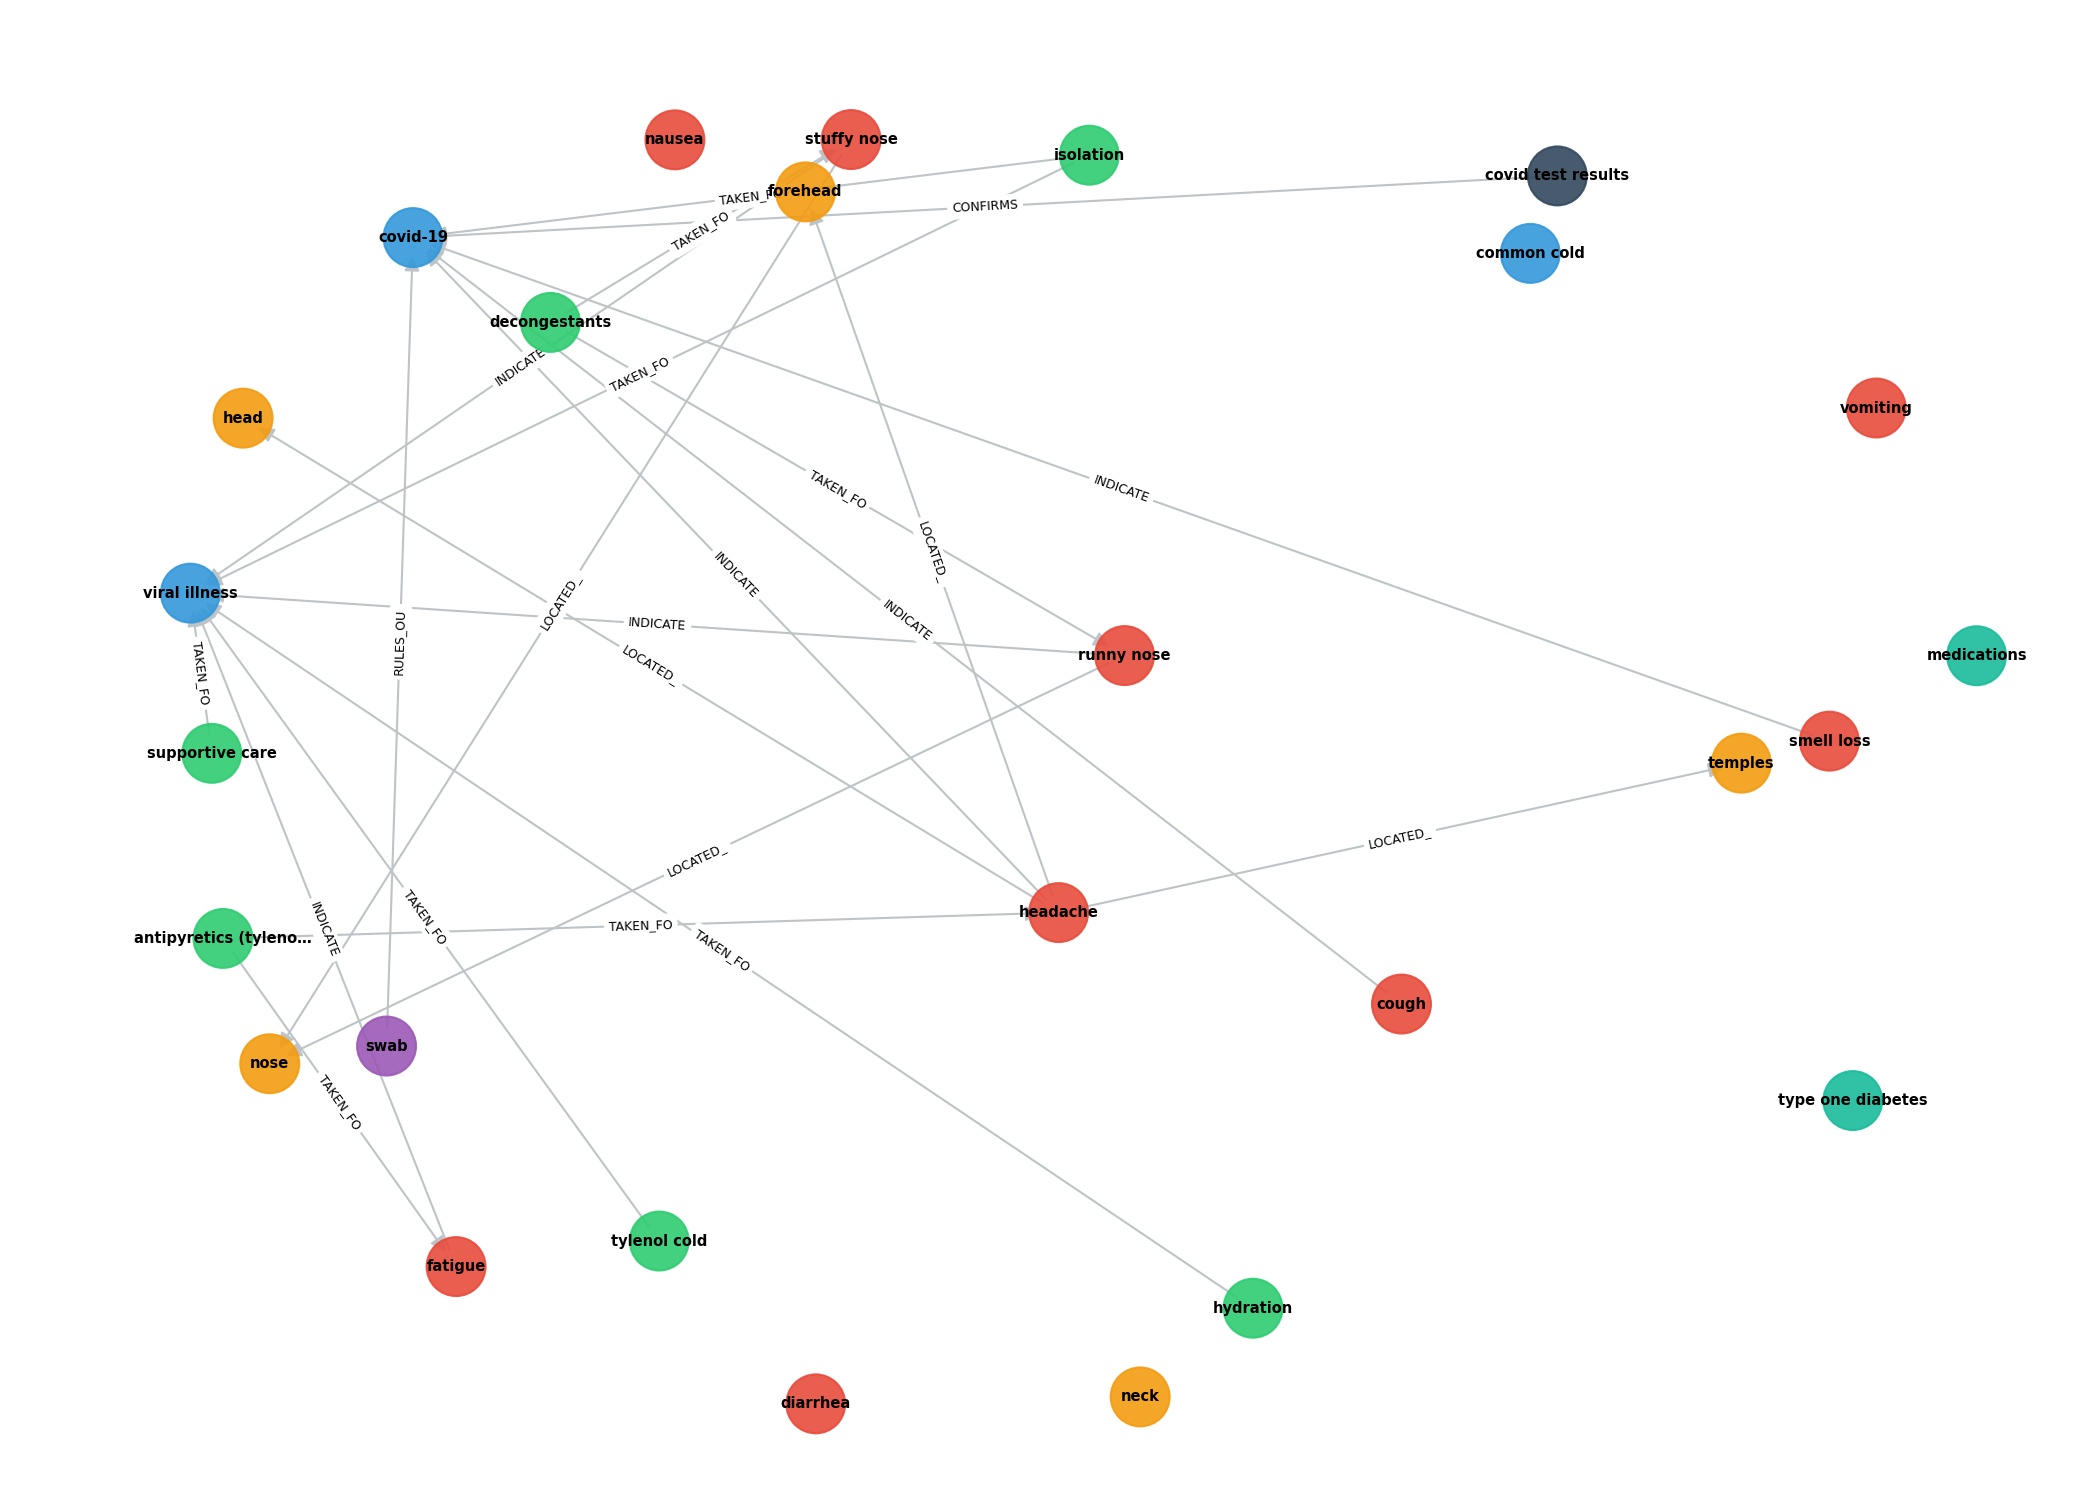

In [8]:
from IPython.display import Image, display
display(Image(filename="./my_kg_naive/kg_graph.png"))

# Check OpenRouter credits [Optional]

In [9]:
os.environ['API_KEY'] = OPENROUTER_KEY  # Uses key set in Step 1
!uv run python -m Clinical_KG_OS_LLM.check_openrouter_credits

💳 API Key Credit Balance:
   Key limit:    $1.00
   Key usage:    $0.13
   Remaining:    $0.87


## Done

Pipeline complete. Results:
- **QA answers:** `./my_kg_naive/results_unified_graph_my_kg/`
- **KG graph:** `./my_kg_naive/kg_graph.png`
- **Step 7 (LLM Judge):** Optional, ~$8–10 per run — executed by hackathon organizers only.